In [4]:
import sys
import os

current_dir = os.path.dirname(os.path.abspath(''))
others_path = os.path.join(current_dir, '..', '..', 'gpr')

others_path = os.path.abspath(others_path)
if others_path not in sys.path:
    sys.path.append(others_path)

from pathlib import Path
analy_script_path = Path.cwd().parent.parent.parent / 'analysis'
if str(analy_script_path) not in sys.path:
    sys.path.append(str(analy_script_path))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

import corner
import seaborn as sb
from scipy.integrate import cumulative_simpson as cumsimp
from eos import EosProperties
from kernels import Kernel
import gaussianprocess
from constrainedgp import CGP
import sampling as sam
import prepare_ceft as pc
import prepare_pqcd as pp
import anal_helpers as anal
from pqcd.pQCD import pQCD
from constants import get_phi, ns
import tmg_samplers as tmg
import constrain_on_chempot as coc
import post_anal as pa



from aquarel import load_theme
theme_notused = (
        load_theme("gruvbox_dark")
        .set_font("serif")
        .set_grid(True, width=0.2)
        )

theme = (
        load_theme("scientific")
        .set_font(family="serif", serif=["cmr10"]) # useless since text.usetex is set to True
        .set_grid(True, width=0.2)
        .set_lines(width=2)
        .set_axes(top=True, right=True, width=1.5)
        .set_ticks(width_major=1.2, width_minor=0.9, size_major=11, size_minor=4, direction='in')
        .set_tick_labels(size="xx-large") # large for single plot, xx-large for 2 subplots. need to change it in this line!!
        .set_overrides({
            "ytick.right": "true",
            "xtick.top": "true",
            "axes.formatter.use_mathtext": "True",
            'mathtext.fontset':'cm',
            "text.usetex":"True"
        })
        .set_title(pad=15)
        .set_axis_labels(weight="roman", size="x-large")
        .set_legend(text_size="large")
        )
theme.apply()
big_fontsize = 20
solo_fontsize = 16
cols = ['#ffac00', '#4e3fee', '#ea1900', '#8EC7D2', "#DC267F"]

plot_dir = "/home/sam/thesis/writing/images/"

In [2]:
eos = np.load("/home/sam/thesis/code/results/eos_samples/integral_obs/eos.npy")
X_eos = np.load("/home/sam/thesis/code/results/eos_samples/integral_obs/renormscale.npy")
n_test_test = anal.get_n_test(45,400)

n_ceft, cs2_ceft, cs2_l, cs2_u = anal.get_ceft_cs2()
_, e_ceft, e_ceft_l, e_ceft_u = anal.get_ceft("epsilon")
_, p_ceft, p_ceft_l, p_ceft_u = anal.get_ceft("pressure")
_, mu_ceft, mu_ceft_l, mu_ceft_u = anal.get_ceft("mu")

crust = np.loadtxt("/home/sam/thesis/code/gpr/EOS/chiEFT/crust.dat").T
n_crust = crust[0]
e_crust = crust[1]
p_crust = crust[2]
cs2_crust = crust[3]

e_ini = e_crust[-1]
p_ini = p_crust[-1]
mu_ini = (p_ini + e_ini) / n_crust[-1]

n_ceft, cs2_ceft, cs2_ceft_l, cs2_ceft_u = anal.get_ceft_cs2()

In [3]:
def pqcd_residual(p_gp, p_pqcd, n_qcd, n_test_test=None):

    idx = np.searchsorted(n_qcd, n_test_test[-1]) # find index where n_test_test max would fit in n_qcd
    n_qcd = n_qcd[:idx]
    p_pqcd = p_pqcd[:idx]
    p_qp_interp = np.interp(n_qcd, n_test_test, p_gp)

    res = (p_pqcd - p_qp_interp)/p_pqcd * 100  # percentage difference
    return res

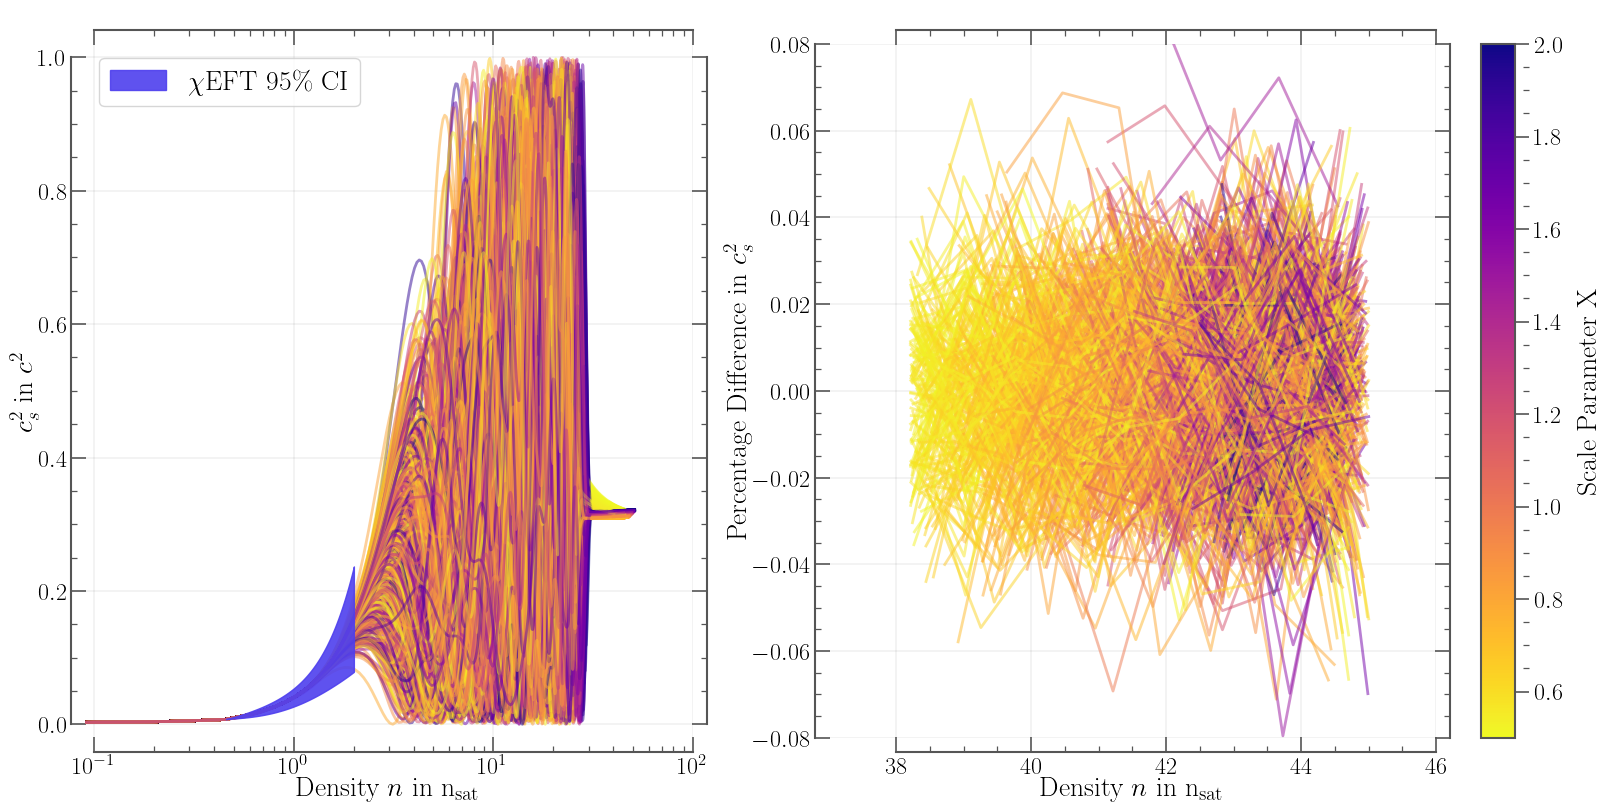

In [ ]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(16,8), sharey=False, constrained_layout=True)

array = np.geomspace(1/2, 2, 100)
norm = mcolors.Normalize(vmin=array.min(), vmax=array.max())
colormap = cm.plasma_r

for i in range(eos.shape[1]):
    eos_eg = eos[:, i,:]
    e_eg, p_eg, cs2_eq = eos_eg[0], eos_eg[1], eos_eg[2]

    mu_grid = np.linspace(2.6, 2.75, 10)

    pQCD_temp = pQCD(X_eos[i])
    array_index = np.searchsorted(array, X_eos[i])
    color = colormap(norm(array[array_index])) 

    n_qcd = np.vectorize(pQCD_temp.number_density)(mu_grid) / ns  # in nsat
    cs2_pqcd = np.vectorize(pQCD_temp.speed2)(mu_grid)


    axL.plot(n_test_test, cs2_eq, color=color, alpha=0.5)
    axL.plot(n_qcd, cs2_pqcd, color=color, alpha=0.5)

    res = pqcd_residual(cs2_eq, cs2_pqcd, n_qcd, n_test_test)

    idx = np.searchsorted(n_qcd, n_test_test[-1]) # find index where n_test_test max would fit in n_qcd
    n_qcd = n_qcd[:idx]
    axR.plot(n_qcd, res, color=color, alpha=0.5)


#axL.plot(n_ceft, cs2_ceft, 'r--', label='CEFT data')
axL.fill_between(n_ceft, cs2_ceft_l, cs2_ceft_u, color=cols[1], alpha=0.9, label=r'$\chi$EFT 95\% CI', zorder=10)

sm = cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array(array)  
cbar = plt.colorbar(sm, ax=plt.gca()) 
cbar.set_label('Scale Parameter X', fontsize=big_fontsize, labelpad=10)

axL.set_ylabel(r"$c_s^2$ in $c^2$", fontsize=big_fontsize)
axL.set_xlabel(r'Density $n$ in n$_{\mathrm{sat}}$', fontsize=big_fontsize)
axL.set_xscale('log')
axL.set_xlim(0.09,100)

axR.set_xlabel(r'Density $n$ in n$_{\mathrm{sat}}$', fontsize=big_fontsize)
axR.set_ylabel(r'Percentage Difference in $c_s^2$', fontsize=big_fontsize)
axR.set_xlim(37,46)
axR.set_ylim(-0.08, 0.08)

axL.set_title(" ")
axR.set_title(" ")

axL.legend(loc='upper left', fontsize=big_fontsize)
theme.apply()
theme.apply_transforms()
#axL.set_xlim(0,2)
#axL.set_ylim(940,1100)
plt.savefig(plot_dir + "cs2_integral_obs.png", dpi=300)
plt.show()

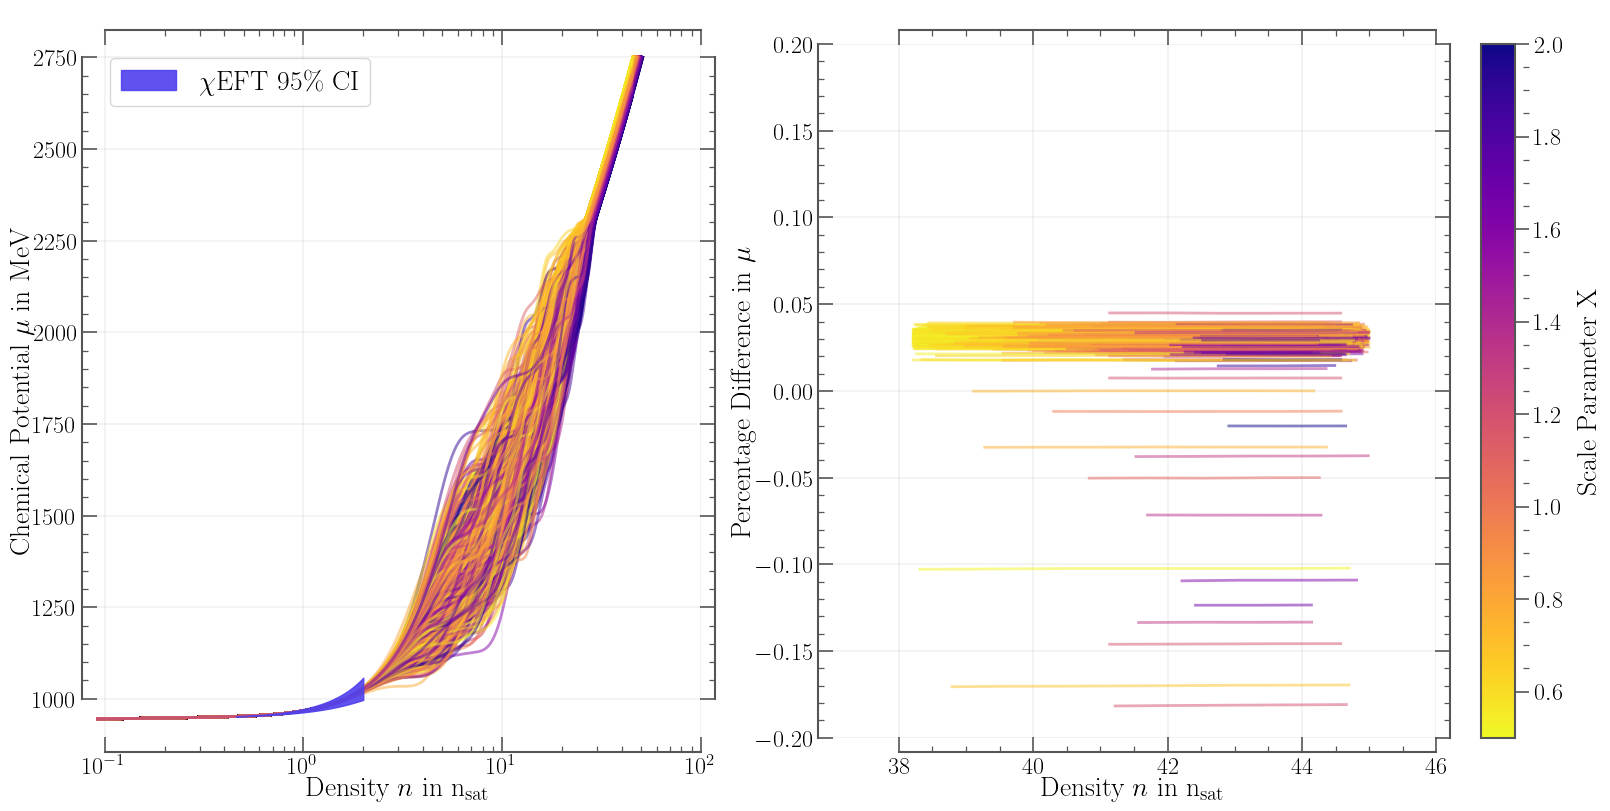

In [49]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(16,8), sharey=False, constrained_layout=True)

array = np.geomspace(1/2, 2, 100)
norm = mcolors.Normalize(vmin=array.min(), vmax=array.max())
colormap = cm.plasma_r

for i in range(eos.shape[1]):
    eos_eg = eos[:, i,:]
    e_eg, p_eg, cs2_eq = eos_eg[0], eos_eg[1], eos_eg[2]

    mu_grid = np.linspace(2.6, 2.75, 10)


    eos_obj = EosProperties(n = n_test_test*ns, phi=None, 
                        epsi_0=e_crust[0], p_0=p_crust[0], 
                        mu_0=(e_crust[0]+p_crust[0])/n_crust[0], cs2 = cs2_eq)
    mu_eg = eos_obj.get_mu()

    pQCD_temp = pQCD(X_eos[i])
    array_index = np.searchsorted(array, X_eos[i])
    color = colormap(norm(array[array_index])) 

    n_qcd = np.vectorize(pQCD_temp.number_density)(mu_grid) / ns  # in nsat
    


    axL.plot(n_test_test, mu_eg, color=color, alpha=0.5)
    axL.plot(n_qcd, mu_grid*1000, color=color, alpha=0.1)

    res = pqcd_residual((mu_eg), (mu_grid*1000), n_qcd, n_test_test)

    idx = np.searchsorted(n_qcd, n_test_test[-1]) # find index where n_test_test max would fit in n_qcd
    n_qcd = n_qcd[:idx]
    axR.plot(n_qcd, res, color=color, alpha=0.5)


axL.fill_between(n_ceft, mu_ceft_l, mu_ceft_u, color=cols[1], alpha=0.9, label=r'$\chi$EFT 95\% CI', zorder=10)

sm = cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array(array)  
cbar = plt.colorbar(sm, ax=plt.gca()) 
cbar.set_label('Scale Parameter X', fontsize=big_fontsize, labelpad=10)

axL.set_ylabel(r"Chemical Potential $\mu$ in MeV", fontsize=big_fontsize)
axL.set_xlabel(r'Density $n$ in n$_{\mathrm{sat}}$', fontsize=big_fontsize)
axL.set_xscale('log')
axL.set_xlim(0.09,100)

axR.set_xlabel(r'Density $n$ in n$_{\mathrm{sat}}$', fontsize=big_fontsize)
axR.set_ylabel(r'Percentage Difference in $\mu$', fontsize=big_fontsize)
axR.set_xlim(37,46)
axR.set_ylim(-0.2,0.2)

axL.set_title(" ")
axR.set_title(" ")

axL.legend(loc='upper left', fontsize=big_fontsize)
theme.apply()
theme.apply_transforms()
#axL.set_xlim(0,2)
#axL.set_ylim(940,1100)
plt.savefig(plot_dir + "mu_integral_obs.png", dpi=300)
plt.show()

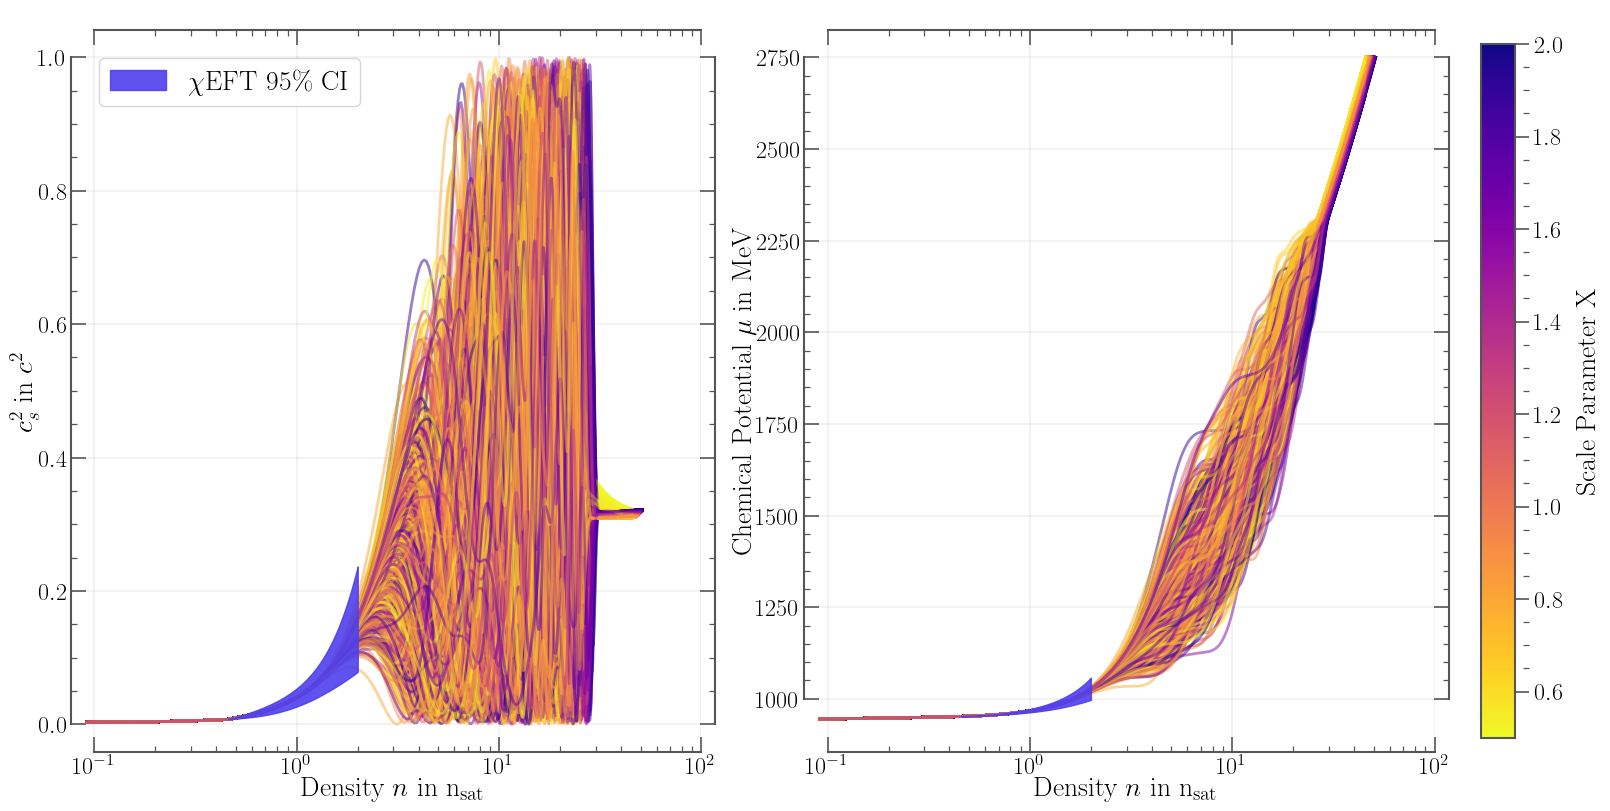

In [78]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(16,8), sharey=False, constrained_layout=True)

array = np.geomspace(1/2, 2, 100)
norm = mcolors.Normalize(vmin=array.min(), vmax=array.max())
colormap = cm.plasma_r

for i in range(eos.shape[1]):
    eos_eg = eos[:, i,:]
    e_eg, p_eg, cs2_eq = eos_eg[0], eos_eg[1], eos_eg[2]

    mu_grid = np.linspace(2.6, 2.75, 10)

    pQCD_temp = pQCD(X_eos[i])
    array_index = np.searchsorted(array, X_eos[i])
    color = colormap(norm(array[array_index])) 

    n_qcd = np.vectorize(pQCD_temp.number_density)(mu_grid) / ns  # in nsat
    cs2_pqcd = np.vectorize(pQCD_temp.speed2)(mu_grid)


    axL.plot(n_test_test, cs2_eq, color=color, alpha=0.5)
    axL.plot(n_qcd, cs2_pqcd, color=color, alpha=0.5)

    eos_obj = EosProperties(n = n_test_test*ns, phi=None, 
                        epsi_0=e_crust[0], p_0=p_crust[0], 
                        mu_0=(e_crust[0]+p_crust[0])/n_crust[0], cs2 = cs2_eq)
    mu_eg = eos_obj.get_mu()

    axR.plot(n_test_test, mu_eg, color=color, alpha=0.5)
    axR.plot(n_qcd, mu_grid*1000, color=color, alpha=0.1)


#axL.plot(n_ceft, cs2_ceft, 'r--', label='CEFT data')
axL.fill_between(n_ceft, cs2_ceft_l, cs2_ceft_u, color=cols[1], alpha=0.9, label=r'$\chi$EFT 95\% CI', zorder=10)
axR.fill_between(n_ceft, mu_ceft_l, mu_ceft_u, color=cols[1], alpha=0.9, label=r'$\chi$EFT 95\% CI', zorder=10)

sm = cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array(array)  
cbar = plt.colorbar(sm, ax=plt.gca()) 
cbar.set_label('Scale Parameter X', fontsize=big_fontsize, labelpad=10)

axL.set_ylabel(r"$c_s^2$ in $c^2$", fontsize=big_fontsize)
axL.set_xlabel(r'Density $n$ in n$_{\mathrm{sat}}$', fontsize=big_fontsize)
axL.set_xscale('log')
axL.set_xlim(0.09,100)

axR.set_ylabel(r"Chemical Potential $\mu$ in MeV", fontsize=big_fontsize)
axR.set_xlabel(r'Density $n$ in n$_{\mathrm{sat}}$', fontsize=big_fontsize)
axR.set_xscale('log')
axR.set_xlim(0.09,100)

axL.set_title(" ")
axR.set_title(" ")

axL.legend(loc='upper left', fontsize=big_fontsize)
theme.apply()
theme.apply_transforms()
#axL.set_xlim(0,2)
#axL.set_ylim(940,1100)
plt.savefig(plot_dir + "cs2_mu_integral_obs.png", dpi=300)
plt.show()

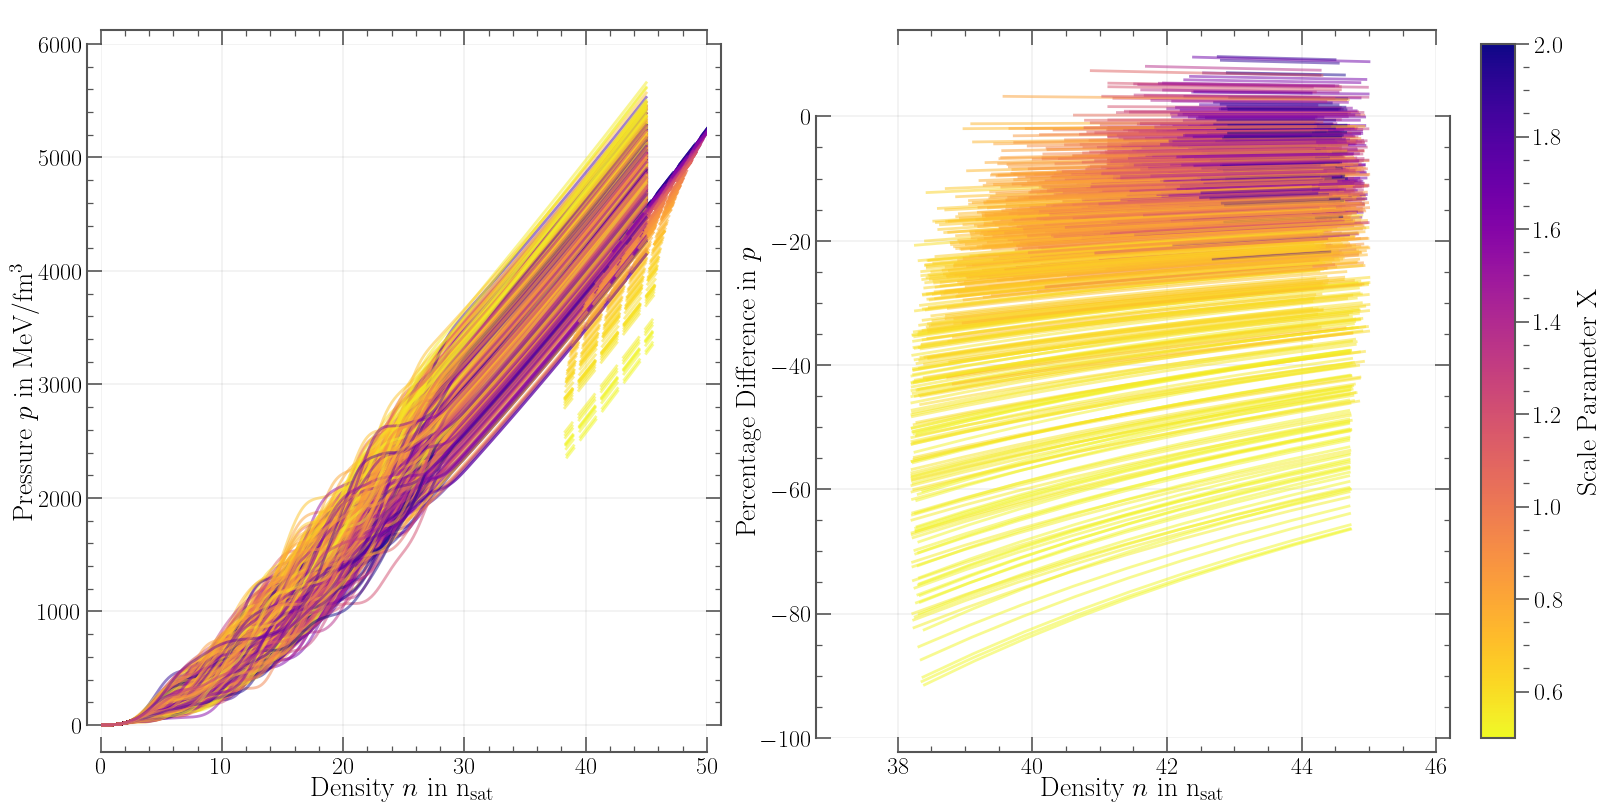

In [5]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(16,8), sharey=False, constrained_layout=True)

array = np.geomspace(1/2, 2, 100)
norm = mcolors.Normalize(vmin=array.min(), vmax=array.max())
colormap = cm.plasma_r

for i in range(eos.shape[1]):
    eos_eg = eos[:, i,:]
    e_eg, p_eg, cs2_eq = eos_eg[0], eos_eg[1], eos_eg[2]

    mu_grid = np.linspace(2.6, 2.75, 10)

    pQCD_temp = pQCD(X_eos[i])
    array_index = np.searchsorted(array, X_eos[i])
    color = colormap(norm(array[array_index])) 

    n_qcd = np.vectorize(pQCD_temp.number_density)(mu_grid) / ns  # in nsat
    press_qcd = np.vectorize(pQCD_temp.pressure)(mu_grid) * 1000  # MeV/fm3

    axL.plot((n_test_test), p_eg, color=color, alpha=0.5)

    if i%5 == 0:
        axL.plot((n_qcd), press_qcd, color=color, alpha=0.5, linestyle=(5, (10, 3)))

    res = pqcd_residual(p_eg, press_qcd, n_qcd, n_test_test)
    
    idx = np.searchsorted(n_qcd, n_test_test[-1]) # find index where n_test_test max would fit in n_qcd
    n_qcd = n_qcd[:idx]
    axR.plot(n_qcd, res, color=color, alpha=0.5)


sm = cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array(array)  
cbar = plt.colorbar(sm, ax=plt.gca()) 
cbar.set_label('Scale Parameter X', fontsize=big_fontsize, labelpad=10)


axL.set_xlabel(r'Density $n$ in n$_{\mathrm{sat}}$', fontsize=big_fontsize)
axL.set_ylabel(r"Pressure $p$ in MeV/fm$^3$", fontsize=big_fontsize)
axL.set_xlim(0,50)
axL.set_ylim(top=6000)

axR.set_xlabel(r'Density $n$ in n$_{\mathrm{sat}}$', fontsize=big_fontsize)
axR.set_ylabel(r'Percentage Difference in $p$', fontsize=big_fontsize)
axR.set_xlim(37,46)
axR.set_ylim(-100,)

axL.set_title(" ")
axR.set_title(" ")
theme.apply()
theme.apply_transforms()

plt.savefig(plot_dir + "p_integral_obs.png", dpi=300)

plt.show()
